In [1]:
# ============================================================
# THUNDERSTORM ENSEMBLE MODEL
# PART 1 - IMPORTS
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import *

from sklearn.linear_model import LogisticRegression

np.random.seed(42)

print("Libraries Loaded")

Libraries Loaded


In [2]:
# ============================================================
# FOLDER STRUCTURE
# ============================================================

BASE_DIR = ".."

DATA_DIR = os.path.join(BASE_DIR,"Data")

RESULT_DIR = os.path.join(BASE_DIR,"Results")

MODEL_DIR = os.path.join(BASE_DIR,"Models")

os.makedirs(RESULT_DIR,exist_ok=True)

os.makedirs(MODEL_DIR,exist_ok=True)

print(DATA_DIR)

..\Data


In [3]:
# ============================================================
# LOAD DATASETS
# ============================================================

train_df = pd.read_csv(

    os.path.join(

        DATA_DIR,

        "train_2000_2020.csv"

    )

)

valid_df = pd.read_csv(

    os.path.join(

        DATA_DIR,

        "validation_2021_2022.csv"

    )

)

test_df = pd.read_csv(

    os.path.join(

        DATA_DIR,

        "test_2023_2025.csv"

    )

)

print(train_df.shape)

print(valid_df.shape)

print(test_df.shape)

(9619, 28)
(580, 28)
(1392, 28)


In [4]:
# ============================================================
# PREPROCESSING
# ============================================================

TARGET="Thunderstorm_24h"

DROP=[]

for c in ["Date","Time"]:

    if c in train_df.columns:

        DROP.append(c)

train_df=train_df.drop(columns=DROP)

valid_df=valid_df.drop(columns=DROP)

test_df=test_df.drop(columns=DROP)

X_train=train_df.drop(columns=[TARGET])

y_train=train_df[TARGET]

X_valid=valid_df.drop(columns=[TARGET])

y_valid=valid_df[TARGET]

X_test=test_df.drop(columns=[TARGET])

y_test=test_df[TARGET]

print(X_train.shape)

(9619, 25)


In [5]:
# ============================================================
# LOAD MODELS
# ============================================================

cat_model = joblib.load(

    os.path.join(

        DATA_DIR,

        "CatBoost_Final_Research_Model.pkl"

    )

)

lgb_model = joblib.load(

    os.path.join(

        DATA_DIR,

        "LightGBM_Thunderstorm_Model.pkl"

    )

)

xgb_model = joblib.load(

    os.path.join(

        DATA_DIR,

        "XGBoost_Final.pkl"

    )

)

print("All Models Loaded")

All Models Loaded


In [6]:
# ============================================================
# VALIDATION PROBABILITIES
# ============================================================

cat_valid = cat_model.predict_proba(

    X_valid

)[:,1]

lgb_valid = lgb_model.predict_proba(

    X_valid

)[:,1]

xgb_valid = xgb_model.predict_proba(

    X_valid

)[:,1]

print(cat_valid.shape)

[LightGBM] [Warning] feature_fraction is set=0.9207116051626851, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9207116051626851
[LightGBM] [Warning] lambda_l1 is set=4.332378684164573, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.332378684164573
[LightGBM] [Warning] lambda_l2 is set=7.8246451974311855, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.8246451974311855
[LightGBM] [Warning] bagging_fraction is set=0.9076559034865189, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9076559034865189
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
(580,)


In [7]:
# ============================================================
# TEST PROBABILITIES
# ============================================================

cat_test = cat_model.predict_proba(

    X_test

)[:,1]

lgb_test = lgb_model.predict_proba(

    X_test

)[:,1]

xgb_test = xgb_model.predict_proba(

    X_test

)[:,1]

print(cat_test.shape)

[LightGBM] [Warning] feature_fraction is set=0.9207116051626851, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9207116051626851
[LightGBM] [Warning] lambda_l1 is set=4.332378684164573, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.332378684164573
[LightGBM] [Warning] lambda_l2 is set=7.8246451974311855, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.8246451974311855
[LightGBM] [Warning] bagging_fraction is set=0.9076559034865189, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9076559034865189
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
(1392,)


In [8]:
# ============================================================
# INDIVIDUAL MODEL PERFORMANCE
# ============================================================

print("Validation ROC-AUC")

print()

print(

"CatBoost :",

roc_auc_score(

y_valid,

cat_valid

)

)

print(

"LightGBM :",

roc_auc_score(

y_valid,

lgb_valid

)

)

print(

"XGBoost :",

roc_auc_score(

y_valid,

xgb_valid

)

)

Validation ROC-AUC

CatBoost : 0.8537944672913997
LightGBM : 0.84136722173532
XGBoost : 0.8576597226903975


In [9]:
# ============================================================
# SAVE VALIDATION PROBABILITIES
# ============================================================

validation_probabilities=pd.DataFrame({

"Actual":y_valid,

"CatBoost":cat_valid,

"LightGBM":lgb_valid,

"XGBoost":xgb_valid

})

validation_probabilities.to_csv(

os.path.join(

RESULT_DIR,

"Validation_Probabilities.csv"

),

index=False

)

validation_probabilities.head()

,Actual,CatBoost,LightGBM,XGBoost
0,0,0.004266,0.001888,0.003609
1,0,0.005696,0.001561,0.006215
2,0,0.005058,0.001277,0.006670
3,0,0.004757,0.001089,0.002890
4,0,0.054051,0.013726,0.030224


In [10]:
# ============================================================
# SAVE VALIDATION PROBABILITIES
# ============================================================

validation_probabilities=pd.DataFrame({

"Actual":y_valid,

"CatBoost":cat_valid,

"LightGBM":lgb_valid,

"XGBoost":xgb_valid

})

validation_probabilities.to_csv(

os.path.join(

RESULT_DIR,

"Validation_Probabilities.csv"

),

index=False

)

validation_probabilities.head()

,Actual,CatBoost,LightGBM,XGBoost
0,0,0.004266,0.001888,0.003609
1,0,0.005696,0.001561,0.006215
2,0,0.005058,0.001277,0.006670
3,0,0.004757,0.001089,0.002890
4,0,0.054051,0.013726,0.030224


In [11]:
# ============================================================
# METRIC FUNCTION
# ============================================================

def calculate_metrics(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    csi = tp / (tp + fp + fn + 1e-12)

    far = fp / (tp + fp + 1e-12)

    specificity = tn / (tn + fp + 1e-12)

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "CSI": csi,
        "FAR": far,
        "Specificity": specificity
    }

In [12]:
from itertools import product

In [13]:
# ============================================================
# GENERATE WEIGHT COMBINATIONS
# ============================================================

weights = np.arange(0, 1.01, 0.05)

weight_combinations = []

for w_cat, w_lgb in product(weights, weights):

    w_xgb = 1 - w_cat - w_lgb

    if w_xgb < 0 or w_xgb > 1:
        continue

    weight_combinations.append(

        (

            round(w_cat,2),

            round(w_lgb,2),

            round(w_xgb,2)

        )

    )

print("Total Weight Combinations:", len(weight_combinations))

Total Weight Combinations: 218


In [14]:
# ============================================================
# SEARCH BEST ENSEMBLE (CSI + FAR OPTIMIZATION)
# ============================================================

results = []

best_score = -999

best_weights = None

best_threshold = None

best_metrics = None

for w_cat, w_lgb, w_xgb in weight_combinations:

    # Ensemble Probability
    prob = (
        w_cat * cat_valid +
        w_lgb * lgb_valid +
        w_xgb * xgb_valid
    )

    auc = roc_auc_score(y_valid, prob)

    # Threshold Search
    for threshold in np.arange(0.35, 0.76, 0.01):

        pred = (prob >= threshold).astype(int)

        m = calculate_metrics(y_valid, pred)

        # =====================================================
        # OPTIMIZATION SCORE
        # =====================================================

        score = (
            0.70 * m["CSI"] +
            0.30 * (1 - m["FAR"])
        )

        results.append({

            "CatBoost": w_cat,
            "LightGBM": w_lgb,
            "XGBoost": w_xgb,

            "Threshold": round(threshold,2),

            "Score": score,

            "AUC": auc,

            "Precision": m["Precision"],
            "Recall": m["Recall"],
            "F1": m["F1"],
            "CSI": m["CSI"],
            "FAR": m["FAR"],
            "Specificity": m["Specificity"],

            "TN": m["TN"],
            "FP": m["FP"],
            "FN": m["FN"],
            "TP": m["TP"]

        })

        if score > best_score:

            best_score = score

            best_weights = (
                w_cat,
                w_lgb,
                w_xgb
            )

            best_threshold = threshold

            best_metrics = m

In [15]:
# ============================================================
# BEST ENSEMBLE
# ============================================================

ensemble_results = pd.DataFrame(results)

ensemble_results = ensemble_results.sort_values(

    by="Score",

    ascending=False

)

display(

    ensemble_results.head(20)

)

print("="*60)

print("BEST ENSEMBLE")

print("="*60)

print()

print("CatBoost Weight :",best_weights[0])

print("LightGBM Weight :",best_weights[1])

print("XGBoost Weight  :",best_weights[2])

print()

print("Best Threshold :",round(best_threshold,2))

print()

print("Validation Metrics")

for k,v in best_metrics.items():

    print(f"{k:15s}: {v}")

print()

ensemble_prob = (

    best_weights[0]*cat_valid +

    best_weights[1]*lgb_valid +

    best_weights[2]*xgb_valid

)

print("ROC AUC :",roc_auc_score(

    y_valid,

    ensemble_prob

))

,CatBoost,LightGBM,XGBoost,Threshold,Score,AUC,Precision,Recall,F1,CSI,FAR,Specificity,TN,FP,FN,TP
2691,0.15,0.30,0.55,0.61,0.447165,0.854783,0.543689,0.615385,0.577320,0.405797,0.456311,0.903885,442,47,35,56
1954,0.10,0.35,0.55,0.62,0.447165,0.853772,0.543689,0.615385,0.577320,0.405797,0.456311,0.903885,442,47,35,56
316,0.00,0.35,0.65,0.64,0.446321,0.853233,0.537736,0.626374,0.578680,0.407143,0.462264,0.899796,440,49,34,57
6373,0.45,0.35,0.20,0.53,0.446316,0.853772,0.557895,0.582418,0.569892,0.398496,0.442105,0.914110,447,42,38,53
315,0.00,0.35,0.65,0.63,0.445549,0.853233,0.532110,0.637363,0.580000,0.408451,0.467890,0.895706,438,51,33,58
4496,0.30,0.00,0.70,0.62,0.444410,0.859165,0.585366,0.527473,0.554913,0.384000,0.414634,0.930470,455,34,43,48
1176,0.05,0.35,0.60,0.63,0.443553,0.853390,0.538462,0.615385,0.574359,0.402878,0.461538,0.901840,441,48,35,56
357,0.00,0.40,0.60,0.64,0.443553,0.852761,0.538462,0.615385,0.574359,0.402878,0.461538,0.901840,441,48,35,56
1913,0.10,0.30,0.60,0.62,0.443553,0.854379,0.538462,0.615385,0.574359,0.402878,0.461538,0.901840,441,48,35,56
356,0.00,0.40,0.60,0.63,0.442792,0.852761,0.532710,0.626374,0.575758,0.404255,0.467290,0.897751,439,50,34,57


BEST ENSEMBLE

CatBoost Weight : 0.1
LightGBM Weight : 0.35
XGBoost Weight  : 0.55

Best Threshold : 0.62

Validation Metrics
TN             : 442
FP             : 47
FN             : 35
TP             : 56
Precision      : 0.5436893203883495
Recall         : 0.6153846153846154
F1             : 0.5773195876288659
CSI            : 0.40579710144927245
FAR            : 0.45631067961164606
Specificity    : 0.9038854805725952

ROC AUC : 0.8537719948762894


In [16]:
# ============================================================
# SAVE RESULTS
# ============================================================

ensemble_results.to_csv(

    os.path.join(

        RESULT_DIR,

        "Ensemble_Weight_Search.csv"

    ),

    index=False

)

print("Search Results Saved")

Search Results Saved


In [17]:
# ============================================================
# FINAL ENSEMBLE PREDICTIONS
# ============================================================

CAT_WEIGHT = 0.10
LGB_WEIGHT = 0.35
XGB_WEIGHT = 0.55

BEST_THRESHOLD = 0.62

ensemble_test_prob = (

    CAT_WEIGHT * cat_test +

    LGB_WEIGHT * lgb_test +

    XGB_WEIGHT * xgb_test

)

ensemble_test_pred = (

    ensemble_test_prob >= BEST_THRESHOLD

).astype(int)

print("Prediction Complete")

Prediction Complete


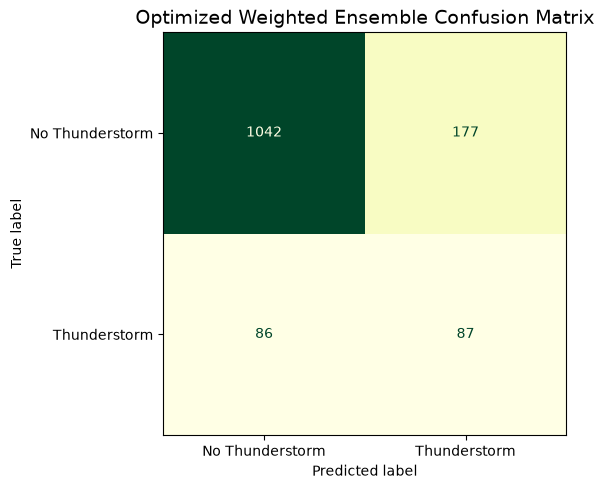

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, ensemble_test_pred)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Thunderstorm", "Thunderstorm"]
)

disp.plot(
    cmap="YlGn",      # Green theme
    values_format="d",
    colorbar=False,
    ax=ax
)

plt.title("Optimized Weighted Ensemble Confusion Matrix", fontsize=14)
plt.tight_layout()

plt.savefig("Ensemble_Confusion_Matrix_Green.png", dpi=300)

plt.show()

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Confusion Matrix values
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_test_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, ensemble_test_pred)
precision = precision_score(y_test, ensemble_test_pred)
recall = recall_score(y_test, ensemble_test_pred)
f1 = f1_score(y_test, ensemble_test_pred)
roc_auc = roc_auc_score(y_test, ensemble_test_prob)

# Weather Metrics
far = fp / (tp + fp)
csi = tp / (tp + fp + fn)

print("="*45)
print("Optimized Weighted Ensemble Results")
print("="*45)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"FAR       : {far:.4f}")
print(f"CSI       : {csi:.4f}")

Optimized Weighted Ensemble Results
Accuracy  : 0.8111
Precision : 0.3295
Recall    : 0.5029
F1 Score  : 0.3982
ROC AUC   : 0.8073
FAR       : 0.6705
CSI       : 0.2486


In [21]:
evaluate_model(
        "Optimized Ensemble",
        y_test,
        ensemble_test_prob,
        ensemble_test_pred
    )

{'Model': 'Optimized Ensemble',
 'TN': np.int64(1042),
 'FP': np.int64(177),
 'FN': np.int64(86),
 'TP': np.int64(87),
 'Accuracy': 0.8110632183908046,
 'Balanced Accuracy': 0.6788445944984756,
 'Precision': 0.32954545454545453,
 'Recall': 0.5028901734104047,
 'Specificity': np.float64(0.8547990155865457),
 'F1': 0.39816933638443935,
 'CSI': np.float64(0.24857142857142783),
 'FAR': np.float64(0.6704545454545429),
 'ROC AUC': 0.807266450753247,
 'MCC': 0.30100534333534057,
 'Kappa': 0.2918291550603528}

In [20]:
CAT_THRESHOLD = 0.32
LGB_THRESHOLD = 0.54
XGB_THRESHOLD = 0.60

cat_pred = (cat_test >= CAT_THRESHOLD).astype(int)

lgb_pred = (lgb_test >= LGB_THRESHOLD).astype(int)

xgb_pred = (xgb_test >= XGB_THRESHOLD).astype(int)

equal_prob = (

    cat_test +
    lgb_test +
    xgb_test

) / 3

equal_pred = (equal_prob >= 0.50).astype(int)

evaluate_model(
        "Equal Ensemble",
        y_test,
        equal_prob,
        equal_pred
    )

{'Model': 'Equal Ensemble',
 'TN': np.int64(1000),
 'FP': np.int64(219),
 'FN': np.int64(69),
 'TP': np.int64(104),
 'Accuracy': 0.7931034482758621,
 'Balanced Accuracy': 0.7107503070364698,
 'Precision': 0.3219814241486068,
 'Recall': 0.6011560693641619,
 'Specificity': np.float64(0.820344544708777),
 'F1': 0.41935483870967744,
 'CSI': np.float64(0.2653061224489789),
 'FAR': np.float64(0.678018575851391),
 'ROC AUC': 0.806664232503663,
 'MCC': 0.32940713535505173,
 'Kappa': 0.3072161527906905}

In [44]:
# ============================================================
# FAIR MODEL COMPARISON
# ============================================================

CAT_THRESHOLD = 0.32
LGB_THRESHOLD = 0.54
XGB_THRESHOLD = 0.60

cat_pred = (cat_test >= CAT_THRESHOLD).astype(int)

lgb_pred = (lgb_test >= LGB_THRESHOLD).astype(int)

xgb_pred = (xgb_test >= XGB_THRESHOLD).astype(int)

equal_prob = (

    cat_test +
    lgb_test +
    xgb_test

) / 3

equal_pred = (equal_prob >= 0.50).astype(int)

comparison = []

comparison.append(
    evaluate_model(
        "CatBoost",
        y_test,
        cat_test,
        cat_pred
    )
)

comparison.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgb_test,
        lgb_pred
    )
)

comparison.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_test,
        xgb_pred
    )
)

comparison.append(
    evaluate_model(
        "Equal Ensemble",
        y_test,
        equal_prob,
        equal_pred
    )
)

comparison.append(
    evaluate_model(
        "Optimized Ensemble",
        y_test,
        ensemble_test_prob,
        ensemble_test_pred
    )
)

comparison.append(
    evaluate_model(
        "Stacking",
        y_test,
        stack_test_prob,
        stack_pred
    )
)

comparison = pd.DataFrame(comparison)

comparison = comparison.sort_values(
    by="F1",
    ascending=False
)

display(comparison)

,Model,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,CSI,FAR,ROC AUC,MCC,Kappa
0,CatBoost,981,238,60,113,0.785920,0.728969,0.321937,0.653179,0.804758,0.431298,0.274939,0.678063,0.799037,0.347898,0.317694
3,Equal Ensemble,1000,219,69,104,0.793103,0.710750,0.321981,0.601156,0.820345,0.419355,0.265306,0.678019,0.806664,0.329407,0.307216
2,XGBoost,980,239,64,109,0.782328,0.716998,0.313218,0.630058,0.803938,0.418426,0.264563,0.686782,0.807091,0.330651,0.302647
5,Stacking,1023,196,78,95,0.803161,0.694173,0.326460,0.549133,0.839212,0.409483,0.257453,0.673540,0.806764,0.315067,0.300428
1,LightGBM,989,230,71,102,0.783764,0.700458,0.307229,0.589595,0.811321,0.403960,0.253102,0.692771,0.805095,0.310353,0.287535
4,Optimized Ensemble,1042,177,86,87,0.811063,0.678845,0.329545,0.502890,0.854799,0.398169,0.248571,0.670455,0.807266,0.301005,0.291829


In [47]:
# ============================================================
# FINAL MODEL RANKING
# ============================================================

ranking = comparison.sort_values(

    by=["F1", "CSI", "Recall"],

    ascending=False

)

print("=" * 70)
print("FINAL MODEL RANKING")
print("=" * 70)

display(ranking)

ranking.to_csv(

    os.path.join(

        RESULT_DIR,

        "Final_Model_Ranking.csv"

    ),

    index=False

)

FINAL MODEL RANKING


,Model,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,CSI,FAR,ROC AUC,MCC,Kappa
0,CatBoost,981,238,60,113,0.785920,0.728969,0.321937,0.653179,0.804758,0.431298,0.274939,0.678063,0.799037,0.347898,0.317694
3,Equal Ensemble,1000,219,69,104,0.793103,0.710750,0.321981,0.601156,0.820345,0.419355,0.265306,0.678019,0.806664,0.329407,0.307216
2,XGBoost,980,239,64,109,0.782328,0.716998,0.313218,0.630058,0.803938,0.418426,0.264563,0.686782,0.807091,0.330651,0.302647
5,Stacking,1023,196,78,95,0.803161,0.694173,0.326460,0.549133,0.839212,0.409483,0.257453,0.673540,0.806764,0.315067,0.300428
1,LightGBM,989,230,71,102,0.783764,0.700458,0.307229,0.589595,0.811321,0.403960,0.253102,0.692771,0.805095,0.310353,0.287535
4,Optimized Ensemble,1042,177,86,87,0.811063,0.678845,0.329545,0.502890,0.854799,0.398169,0.248571,0.670455,0.807266,0.301005,0.291829


In [48]:
# ============================================================
# BEST MODEL
# ============================================================

best = ranking.iloc[0]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

for c in ranking.columns:

    print(f"{c:20s}: {best[c]}")

BEST MODEL
Model               : CatBoost
TN                  : 981
FP                  : 238
FN                  : 60
TP                  : 113
Accuracy            : 0.7859195402298851
Balanced Accuracy   : 0.728968594555378
Precision           : 0.32193732193732194
Recall              : 0.653179190751445
Specificity         : 0.8047579983593103
F1                  : 0.4312977099236641
CSI                 : 0.27493917274939106
FAR                 : 0.6780626780626761
ROC AUC             : 0.7990369249882638
MCC                 : 0.34789797064296013
Kappa               : 0.31769419799263765


<Figure size 1200x600 with 0 Axes>

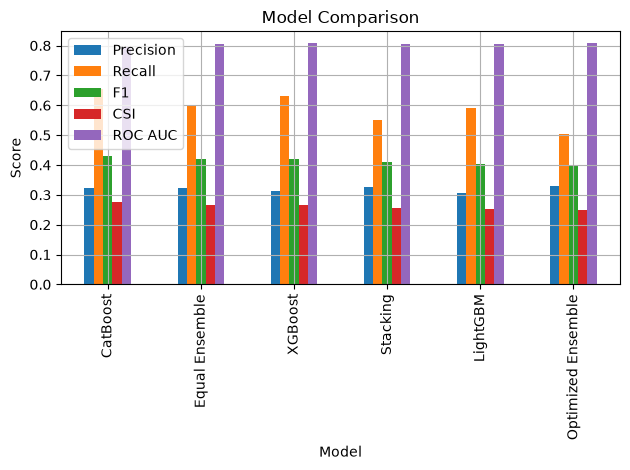

In [49]:
# ============================================================
# PERFORMANCE COMPARISON
# ============================================================

metrics = [

    "Precision",

    "Recall",

    "F1",

    "CSI",

    "ROC AUC"

]

plot_df = comparison.set_index("Model")[metrics]

plt.figure(figsize=(12,6))

plot_df.plot(

    kind="bar"

)

plt.grid(True)

plt.ylabel("Score")

plt.title("Model Comparison")

plt.tight_layout()

plt.savefig(

    os.path.join(

        RESULT_DIR,

        "Model_Comparison.png"

    ),

    dpi=300

)

plt.show()

In [50]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

import joblib

joblib.dump(

    cat_model,

    os.path.join(

        MODEL_DIR,

        "Final_Thunderstorm_Model.pkl"

    )

)

print("Final model saved.")

Final model saved.


In [36]:
# ============================================================
# BUILD STACKING DATASET
# ============================================================

stack_train = pd.DataFrame({

    "CatBoost": cat_valid,
    "LightGBM": lgb_valid,
    "XGBoost": xgb_valid

})

stack_test = pd.DataFrame({

    "CatBoost": cat_test,
    "LightGBM": lgb_test,
    "XGBoost": xgb_test

})

print("Training Shape :", stack_train.shape)
print("Testing Shape  :", stack_test.shape)

display(stack_train.head())

Training Shape : (580, 3)
Testing Shape  : (1392, 3)


,CatBoost,LightGBM,XGBoost
0,0.004266,0.001888,0.003609
1,0.005696,0.001561,0.006215
2,0.005058,0.001277,0.006670
3,0.004757,0.001089,0.002890
4,0.054051,0.013726,0.030224


In [37]:
# ============================================================
# TRAIN META MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(

    random_state=42,
    max_iter=1000

)

meta_model.fit(

    stack_train,
    y_valid

)

print("Stacking Meta Model Trained Successfully")

Stacking Meta Model Trained Successfully


In [38]:
# ============================================================
# META MODEL COEFFICIENTS
# ============================================================

coef = pd.DataFrame({

    "Base Model":[
        "CatBoost",
        "LightGBM",
        "XGBoost"
    ],

    "Coefficient":meta_model.coef_[0]

})

display(coef)

print()

print("Intercept :", meta_model.intercept_[0])

,Base Model,Coefficient
0,CatBoost,1.795199
1,LightGBM,0.868643
2,XGBoost,2.380408



Intercept : -3.4899444245999205


In [39]:
# ============================================================
# STACKING PROBABILITIES
# ============================================================

stack_valid_prob = meta_model.predict_proba(

    stack_train

)[:,1]

stack_test_prob = meta_model.predict_proba(

    stack_test

)[:,1]

print(stack_valid_prob[:10])

print()

print(stack_test_prob[:10])

[0.03011793 0.03036677 0.03035763 0.03007339 0.03526227 0.05032358
 0.03741043 0.03647341 0.03090306 0.03148018]

[0.03431006 0.03269058 0.0308066  0.03418461 0.03267621 0.03079601
 0.03045536 0.03065607 0.03009391 0.03007759]


In [40]:
# ============================================================
# FIND BEST THRESHOLD
# ============================================================

threshold_results=[]

best_threshold=0.50

best_f1=-1

for t in np.arange(0.30,0.71,0.01):

    pred=(stack_valid_prob>=t).astype(int)

    precision=precision_score(

        y_valid,
        pred,
        zero_division=0

    )

    recall=recall_score(

        y_valid,
        pred,
        zero_division=0

    )

    f1=f1_score(

        y_valid,
        pred,
        zero_division=0

    )

    tn,fp,fn,tp=confusion_matrix(

        y_valid,
        pred

    ).ravel()

    csi=tp/(tp+fp+fn+1e-12)

    threshold_results.append({

        "Threshold":round(t,2),
        "Precision":precision,
        "Recall":recall,
        "F1":f1,
        "CSI":csi

    })

    if f1>best_f1:

        best_f1=f1
        best_threshold=t

threshold_results=pd.DataFrame(threshold_results)

display(

    threshold_results.sort_values(

        "F1",

        ascending=False

    ).head(10)

)

print()

print("Best Threshold :",round(best_threshold,2))

,Threshold,Precision,Recall,F1,CSI
1,0.31,0.491667,0.648352,0.559242,0.388158
2,0.32,0.504425,0.626374,0.558824,0.387755
5,0.35,0.536082,0.571429,0.553191,0.382353
0,0.30,0.475806,0.648352,0.548837,0.378205
7,0.37,0.571429,0.527473,0.548571,0.377953
8,0.38,0.573171,0.516484,0.543353,0.373016
4,0.34,0.514851,0.571429,0.541667,0.371429
6,0.36,0.545455,0.527473,0.536313,0.366412
3,0.33,0.495327,0.582418,0.535354,0.365517
9,0.39,0.551282,0.472527,0.508876,0.341270



Best Threshold : 0.31


In [41]:
# ============================================================
# STACKING TEST PREDICTION
# ============================================================

stack_pred=(

    stack_test_prob>=best_threshold

).astype(int)

print("Prediction Complete")

Prediction Complete


In [42]:
# ============================================================
# STACKING PERFORMANCE
# ============================================================

stack_metrics=evaluate_model(

    "Stacking",

    y_test,

    stack_test_prob,

    stack_pred

)

display(

    pd.DataFrame([stack_metrics])

)

,Model,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,CSI,FAR,ROC AUC,MCC,Kappa
0,Stacking,1023,196,78,95,0.803161,0.694173,0.32646,0.549133,0.839212,0.409483,0.257453,0.67354,0.806764,0.315067,0.300428


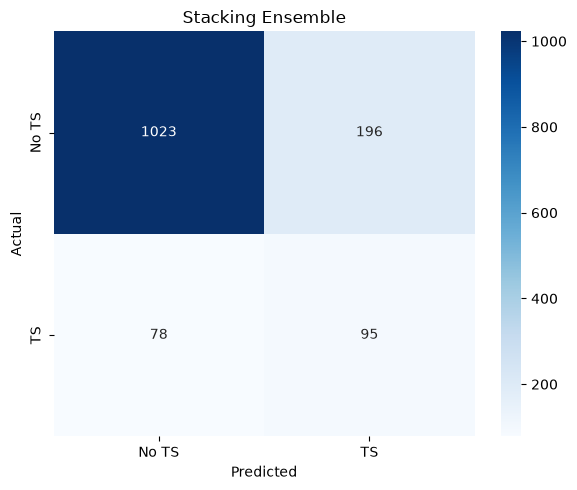

[[1023  196]
 [  78   95]]


In [43]:
# ============================================================
# STACKING CONFUSION MATRIX
# ============================================================

cm=confusion_matrix(

    y_test,

    stack_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["No TS","TS"],

    yticklabels=["No TS","TS"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Stacking Ensemble")

plt.tight_layout()

plt.show()

print(cm)